# 6. Mechanism of action

This tutorial runs on BBBC021, the field's reference benchmark: 38 compounds with published
mechanism labels, at one to seven concentrations each, downloaded and cached by
`mt.ds.bbbc021()`. The images are from Caie et al. 2010; the profiles and the MOA benchmark
are from Ljosa et al. 2013.

The questions are whether a profile tells us what a compound does and, where it does not,
which mechanisms morphology cannot separate.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import mantispy as mt

## From wells to one signature per treatment

The recipe is the one from tutorial 4, with one addition. `pp.normalize` flags features
that have no spread among the control wells. `mad_robustize` divides those by `epsilon`
instead of by zero, so they come back at around 1e17 and dominate every distance computed
afterwards. Feature selection does not catch them, because it measures variance across all
wells.

BBBC021 has two such features, and dropping them adds 8 points of final accuracy.

In [2]:
adata = mt.ds.bbbc021()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")

degenerate = int(adata.var["degenerate_scale"].sum())
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()

{
    "features with no spread among the controls": degenerate,
    "features kept": int(adata.n_vars),
    "treatments": int(signatures.n_obs),
    "mechanisms": int(signatures.obs["Metadata_MOA"].nunique()),
}

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_45201/200299873.py:2: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Dividing by a spread of zero is avoided by adding epsilon=1e-18, which multiplies those features by up to 1e18 and lets them dominate every distance and metric downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). A feature can vary across a plate and still be constant among a handful of control wells, so feature selection does not catch this.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'features with no spread among the controls': 2,
 'features kept': 344,
 'treatments': 103,
 'mechanisms': 12}

103 treatments over 12 mechanisms, the shape of the published benchmark.

## Classifying

`tl.nn_moa_classify` assigns each treatment the mechanism of its nearest neighbor. The
`scheme` decides what the number means:

- `"nn"` allows any neighbor. A compound's nearest neighbor is usually the same compound at
  another concentration, so the task reduces to a profile finding its own compound.
- `"nsc"` (not-same-compound) excludes every neighbor with the same compound. The
  classifier has to generalize from one molecule to a different one with the same
  mechanism. The published benchmark uses this rule.

In [3]:
for scheme in ("nn", "nsc"):
    mt.tl.nn_moa_classify(signatures, scheme=scheme, key_added=scheme)

shares = signatures.obs["Metadata_MOA"].value_counts(normalize=True)
{
    "nn accuracy": round(signatures.uns["mantispy"]["nn"]["accuracy"], 3),
    "not-same-compound accuracy": round(signatures.uns["mantispy"]["nsc"]["accuracy"], 3),
    "largest class share (the honest chance level)": round(float(shares.iloc[0]), 3),
}

{'nn accuracy': 0.951,
 'not-same-compound accuracy': 0.777,
 'largest class share (the honest chance level)': 0.136}

The two schemes give 0.95 and 0.78. The `nn` number mostly measures how well a profile
recognizes its own compound at another dose.

Against a largest-class share of 0.14, not-same-compound retrieval of 0.78 is a strong
result, and it matches what tutorial 4 computes by hand.

## What gets confused with what

An off-diagonal block in the confusion matrix usually reflects biology.

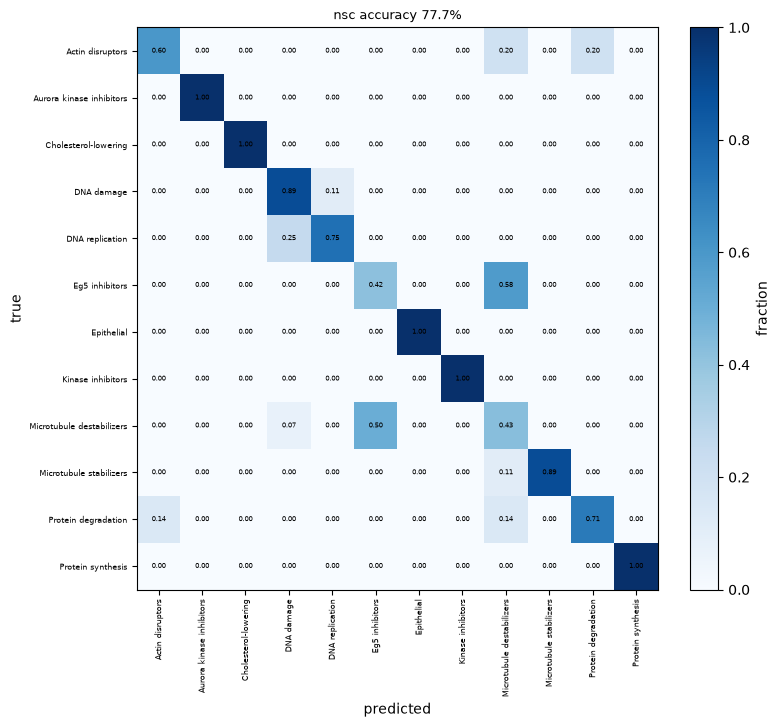

In [4]:
ax = mt.pl.moa_confusion(signatures, key="nsc")
plt.show()

In [5]:
confusion = signatures.uns["mantispy"]["nsc_confusion"]
confusion[confusion["true"] != confusion["predicted"]].nlargest(5, "count")

,true,predicted,count
5,Eg5 inhibitors,Microtubule destabilizers,7
6,Microtubule destabilizers,Eg5 inhibitors,7
14,DNA replication,DNA damage,2
15,Protein degradation,Actin disruptors,1
16,Protein degradation,Microtubule destabilizers,1


The largest confusion is symmetric and biologically expected: Eg5 inhibitors and microtubule
destabilizers, seven treatments each way. Eg5 is the kinesin that separates the centrosomes.
Inhibiting it gives a monopolar spindle, and destabilizing microtubules also arrests mitosis.
At these doses the two look alike under the microscope, which is a limit of the assay rather
than of the classifier.

The second is DNA damage against DNA replication, for the same reason: both stall the cell
cycle and both are read out through the DNA channel.

## Predicting a hidden mechanism

A blind test is more convincing. For each compound in turn, remove its mechanism label, use
`tl.moa_enrichment` to find what its neighborhood is enriched for, and compare the answer with
the removed label. `moa_enrichment` needs no label on the profile it scores, which is the
situation of an uncharacterized compound.

This cell hides each of the 38 compounds in turn, so it is the slowest cell on this page.

In [6]:
compounds = signatures.obs["Metadata_Compound"].astype(str)
truth = signatures.obs.groupby(compounds, observed=True)["Metadata_MOA"].first().astype(str)

records = []
for compound in truth.index:
    blind = signatures.copy()
    blind.obs["Metadata_MOA"] = blind.obs["Metadata_MOA"].astype(str)
    hidden = (blind.obs["Metadata_Compound"].astype(str) == compound).to_numpy()
    blind.obs.loc[hidden, "Metadata_MOA"] = "unknown"

    mt.tl.moa_enrichment(blind, k=10)
    table = blind.uns["mantispy"]["moa_enrichment"]
    asked = set(blind.obs.loc[hidden, "Metadata_Perturbation"].astype(str))
    rows = table[table["group"].isin(asked) & (table["moa"] != "unknown")]
    if rows.empty:
        continue
    predicted = rows.groupby("moa")["pvalue"].min().idxmin()
    records.append({"compound": compound, "true": truth[compound], "predicted": predicted})

blind_test = pd.DataFrame(records)
blind_test["correct"] = blind_test["true"] == blind_test["predicted"]
{
    "compounds tested": len(blind_test),
    "mechanism recovered": int(blind_test["correct"].sum()),
    "rate": round(float(blind_test["correct"].mean()), 3),
}

{'compounds tested': 38, 'mechanism recovered': 26, 'rate': 0.684}

In [7]:
blind_test[~blind_test["correct"]]

,compound,true,predicted,correct
0,ALLN,Protein degradation,Protein synthesis,False
2,AZ-C,Eg5 inhibitors,Microtubule destabilizers,False
4,AZ-U,Epithelial,Protein synthesis,False
8,MG-132,Protein degradation,Microtubule stabilizers,False
11,alsterpaullone,Kinase inhibitors,DNA damage,False
14,camptothecin,DNA replication,DNA damage,False
17,colchicine,Microtubule destabilizers,DNA damage,False
19,cytochalasin B,Actin disruptors,Protein synthesis,False
20,cytochalasin D,Actin disruptors,Protein synthesis,False
25,etoposide,DNA damage,DNA replication,False


Two thirds of the compounds have their mechanism recovered from morphology alone, without the
label, against a chance level of 0.14.

The failures fall into three groups.

Some repeat the confusion matrix. Etoposide and camptothecin swap DNA damage and DNA
replication in both directions, and AZ-C, an Eg5 inhibitor, is predicted as a microtubule
destabilizer. A mechanism that is hard for the nearest-neighbor rule is also hard for the
neighborhood test, so the two methods are consistent.

Some are a whole class. All three actin disruptors miss, each predicted as protein synthesis,
so at these concentrations the actin phenotype does not separate that class in this assay.
All three protein-degradation compounds miss as well: ALLN, MG-132 and lactacystin, three
proteasome inhibitors with three different wrong answers. That is the largest failure on the
page, and it does not appear among the confusion matrix's top pairs because the errors are
spread out. A class that fails in three different directions has no consistent readout in
this assay, which says more than a single confused pair.

One is unexpected: colchicine, a standard microtubule destabilizer, is predicted as DNA
damage. Look at its images before drawing further conclusions about it.

## Which measurements separate the mechanisms

`var` already records which object, measurement family and channel each feature belongs
to. `tl.feature_sets` turns that into a decoupler network, and `tl.enrich` scores every
signature against every set, so the result says which kinds of measurement moved instead of
which individual features.

BBBC021's three channels are DAPI, tubulin and actin. The feature names spell them
`CorrDAPI`, `CorrTub` and `CorrActin` (the `Corr` prefix marks CellProfiler's
illumination-corrected image, and the parser keeps the names as they are), and the table
below uses those names. If the enrichment carries signal, the tubulin-directed mechanisms
should load on the tubulin channel.

In [8]:
mt.tl.enrich(signatures, by="group_by_channel", method="ulm", tmin=5)
mt.tl.rank_sets(signatures, groupby="Metadata_MOA")

ranked = signatures.uns["mantispy"]["rank_sets"]
top = (
    ranked.sort_values("score", ascending=False)
    .groupby("group", observed=True)
    .head(2)
    .sort_values(["group", "score"], ascending=[True, False])
)
top.round(2)

,group,set,score
56,Actin disruptors,Intensity|CorrTub,3.12
55,Actin disruptors,Intensity|CorrDAPI,1.67
7,Aurora kinase inhibitors,Intensity|CorrDAPI,0.96
10,Aurora kinase inhibitors,Texture|CorrDAPI,0.11
69,Cholesterol-lowering,Texture|CorrActin,3.04
70,Cholesterol-lowering,Texture|CorrDAPI,2.99
46,DNA damage,Texture|CorrDAPI,0.10
47,DNA damage,Texture|CorrTub,-0.51
41,DNA replication,Texture|CorrTub,0.78
40,DNA replication,Texture|CorrDAPI,-1.14


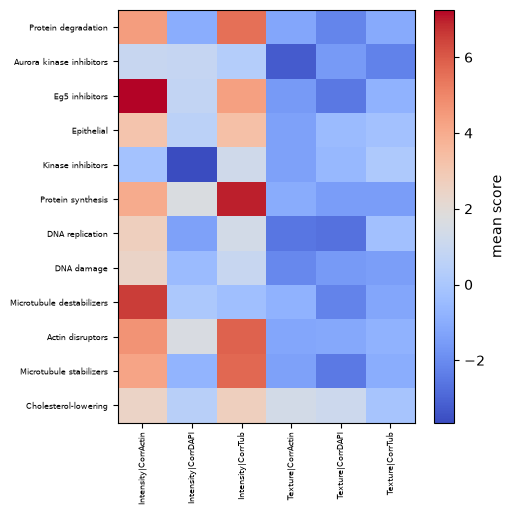

In [9]:
ax = mt.pl.sets_heatmap(signatures, groupby="Metadata_MOA", top=20)
plt.show()

Microtubule stabilizers load most strongly on tubulin intensity. The pipeline was never told
which channel stains microtubules; the channel comes from parsing the feature names, as in
tutorial 1. This result therefore also checks the annotation.

The mapping is not one-to-one. Actin disruptors also score highest on tubulin intensity, and
Eg5 inhibitors on actin. The two cytoskeletal systems are mechanically coupled, and a cell
whose actin has collapsed looks different in every channel. Read the enrichment as which
measurements changed, not as which protein was targeted.

## Distances between mechanisms

`tl.edistance` with `reference=None` gives the full treatment-by-treatment energy
distance matrix, and `pl.distance_heatmap` orders it by mechanism so related treatments sit
together.

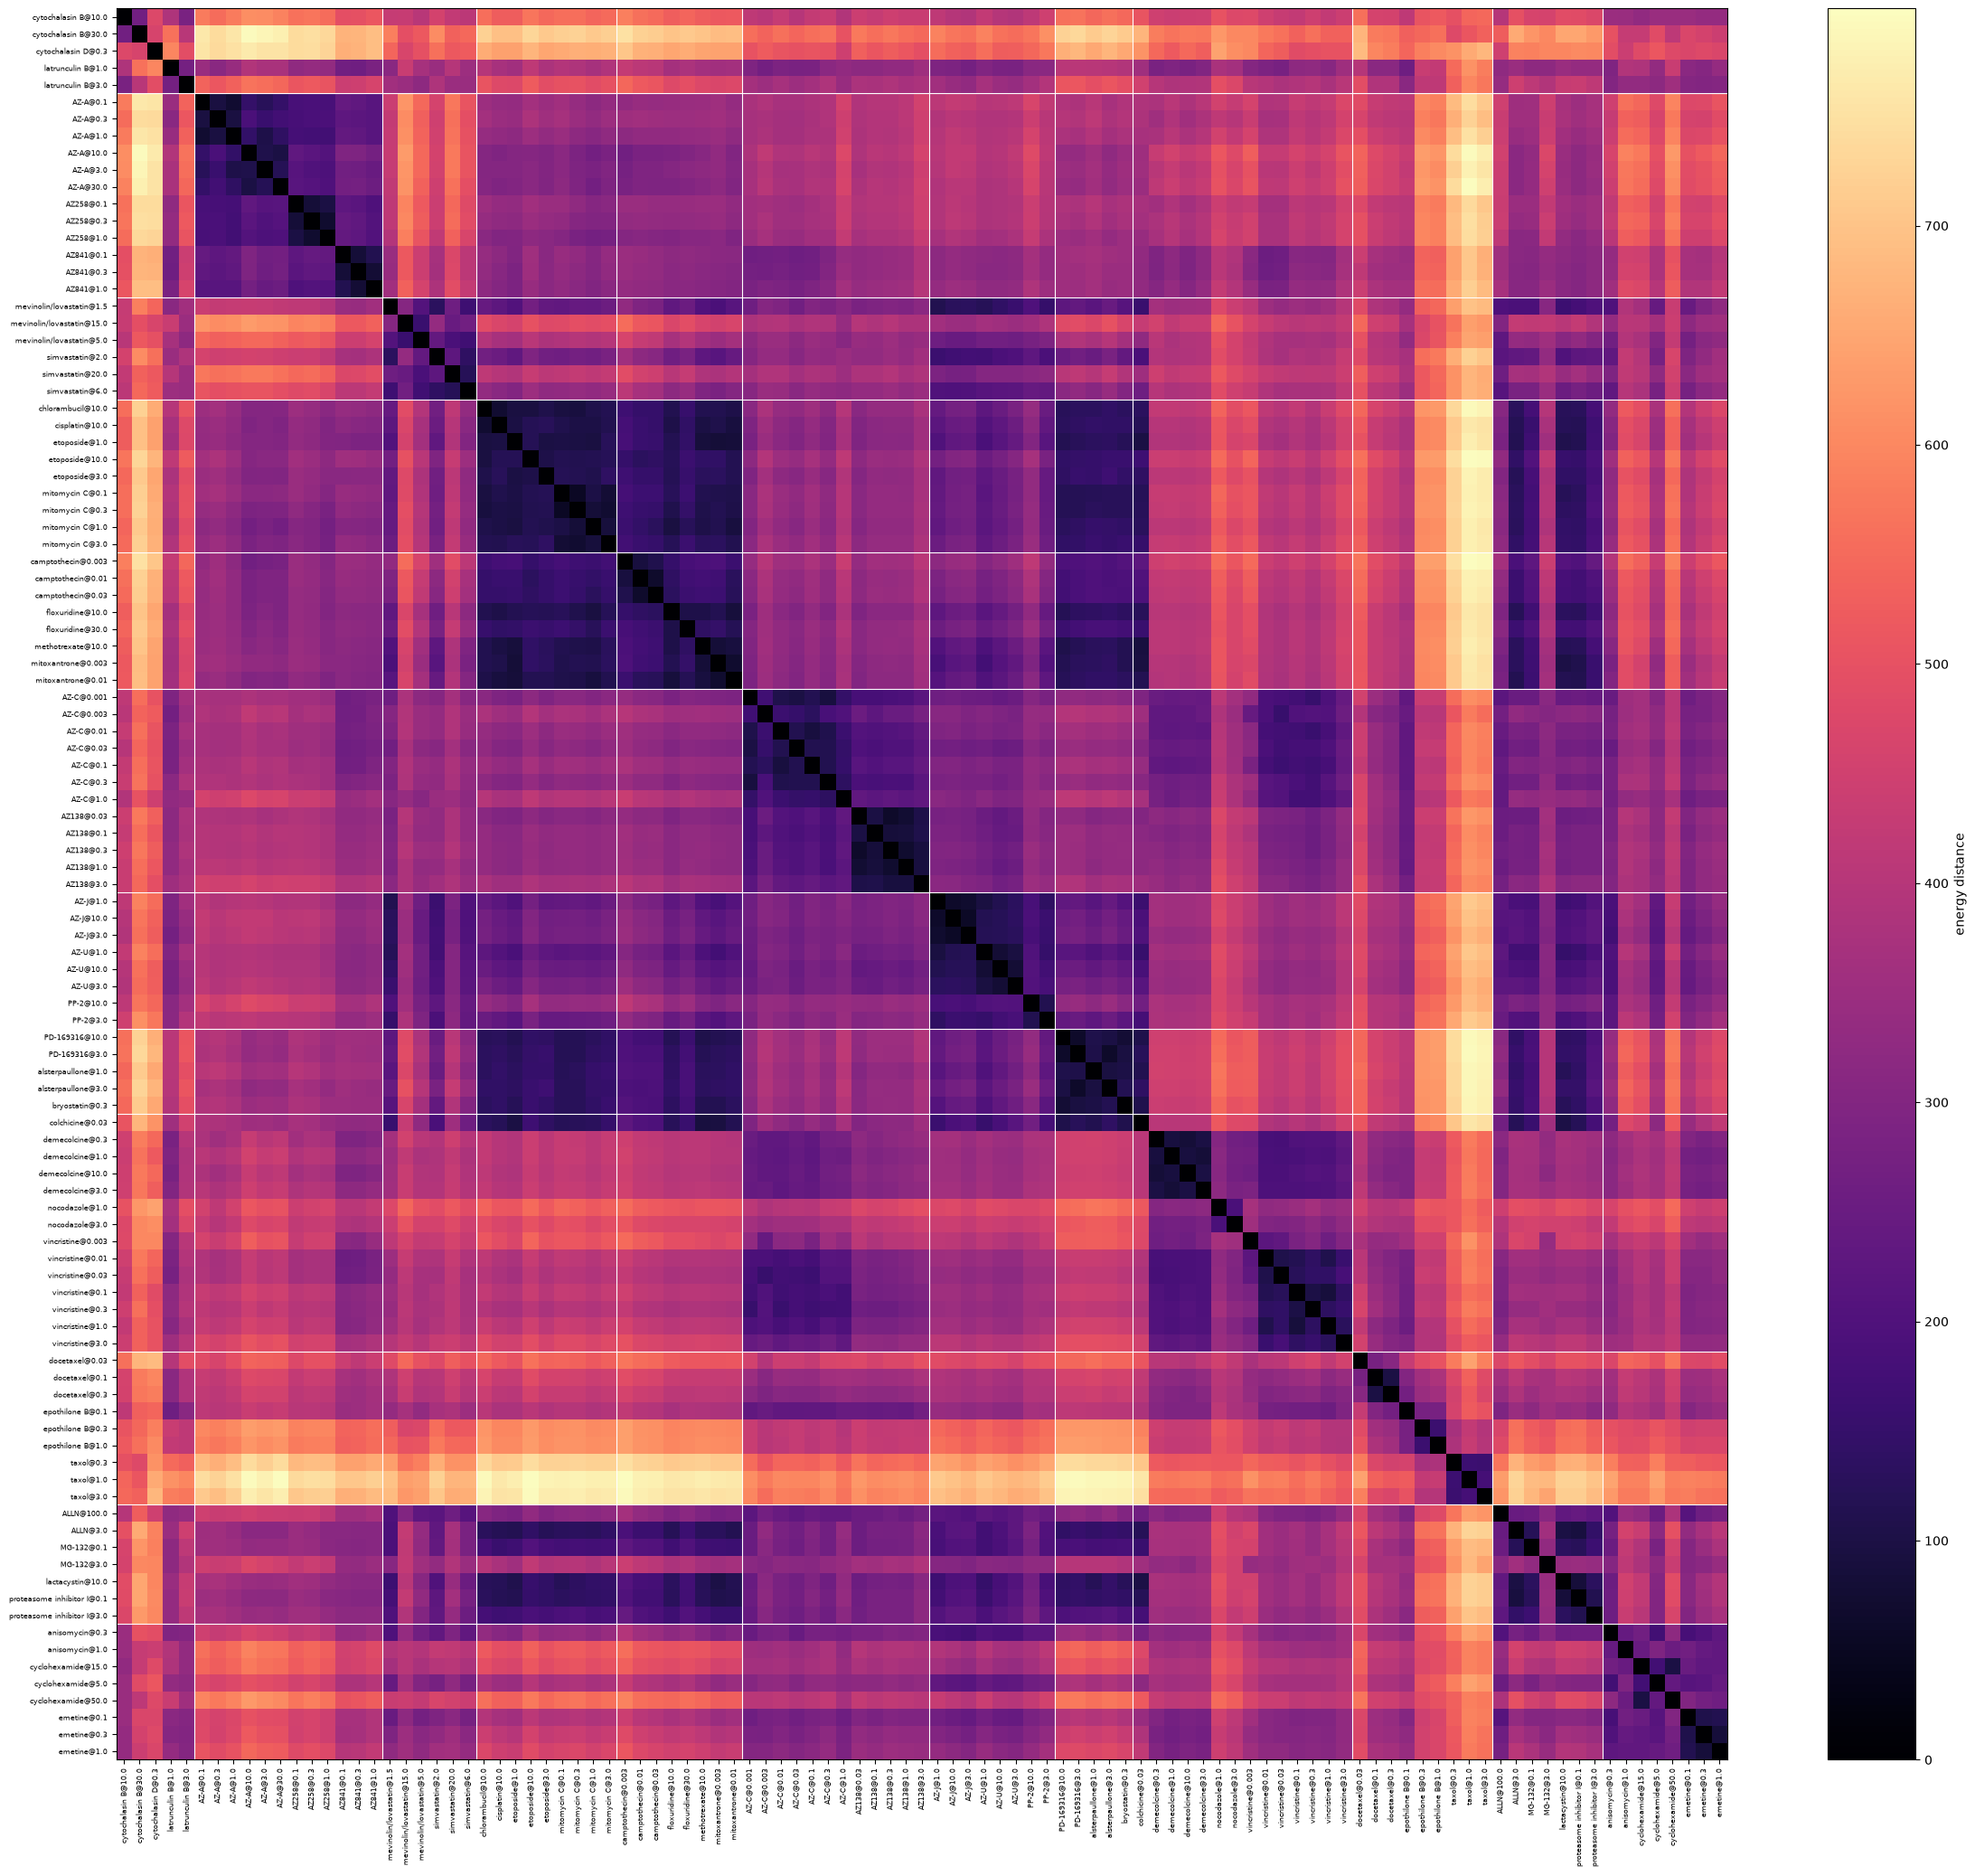

In [10]:
mt.tl.edistance(signatures, reference=None)
ax = mt.pl.distance_heatmap(signatures, groupby="Metadata_MOA")
plt.show()

## Summary

- Report the not-same-compound number, or state which rule you used. The gap between the two
  is large enough to change conclusions.
- Chance is the largest class's share, not one over the number of classes.
- Confusions are hypotheses about the assay. The confusion between Eg5 inhibitors and
  microtubule destabilizers shows what these images can resolve.
- `moa_enrichment` scores a compound without a label, as needed in a screen of
  uncharacterized molecules.

Next: [single-cell heterogeneity](07_single_cell_heterogeneity.ipynb), on what a well
median hides.